In [47]:
import os
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Current working directory:", os.getcwd())

# Project root is the parent of notebooks/
PROJECT_ROOT = Path.cwd().parent

# Key paths
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "merged_players_dataset.csv"
METRICS_PATH = PROJECT_ROOT / "results" / "metrics.json"
PREDICTIONS_PATH = PROJECT_ROOT / "results" / "gb_test_predictions.csv"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("----- Paths Loaded -----")
print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Metrics path:", METRICS_PATH)
print("Predictions path:", PREDICTIONS_PATH)
print("Models directory:", MODELS_DIR)
print("Figures directory:", FIGURES_DIR)


Current working directory: c:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project\notebooks
----- Paths Loaded -----
Project root: c:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project
Data path: c:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project\data\processed\merged_players_dataset.csv
Metrics path: c:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project\results\metrics.json
Predictions path: c:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project\results\gb_test_predictions.csv
Models directory: c:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project\models
Figures directory: c:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project\reports\figures


In [59]:
# Comparison table WITHOUT .style (compatible with all environments)

from pathlib import Path
import json
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parents[0]
METRICS_PATH = PROJECT_ROOT / "results" / "metrics.json"

print("Using metrics file:", METRICS_PATH)

with open(METRICS_PATH, "r") as f:
    metrics = json.load(f)

rows = []

interpretability_map = {
    "baseline": "Very High",
    "linear_regression": "High",
    "ridge": "High",
    "random_forest": "Medium",
    "gradient_boosting": "Low-Medium",
}

for model_name, splits in metrics.items():
    if "val" not in splits:
        continue
    val = splits["val"]
    rows.append({
        "Model": model_name,
        "R² (val)": round(val["r2"], 3),
        "RMSE (val)": round(val["rmse"], 0),
        "MAE (val)": round(val["mae"], 0),
        "Interpretability": interpretability_map.get(model_name, "Unknown"),
    })

val_comparison_df = pd.DataFrame(rows).sort_values("R² (val)", ascending=False)

print("\n📊 Model Comparison (Validation Set):")
print(val_comparison_df.to_string(index=False))


Using metrics file: C:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project\results\metrics.json

📊 Model Comparison (Validation Set):
            Model  R² (val)  RMSE (val)  MAE (val) Interpretability
gradient_boosting     0.724   3003712.0   671679.0       Low-Medium
    random_forest     0.483   4109116.0   835740.0           Medium
         baseline    -0.044   5839999.0  1385020.0        Very High
linear_regression   -70.994  48502099.0  3010809.0             High
            ridge   -71.013  48508395.0  3010644.0             High


Saved R² comparison plot to: C:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project\reports\figures\rf_vs_gb_r2_comparison.png


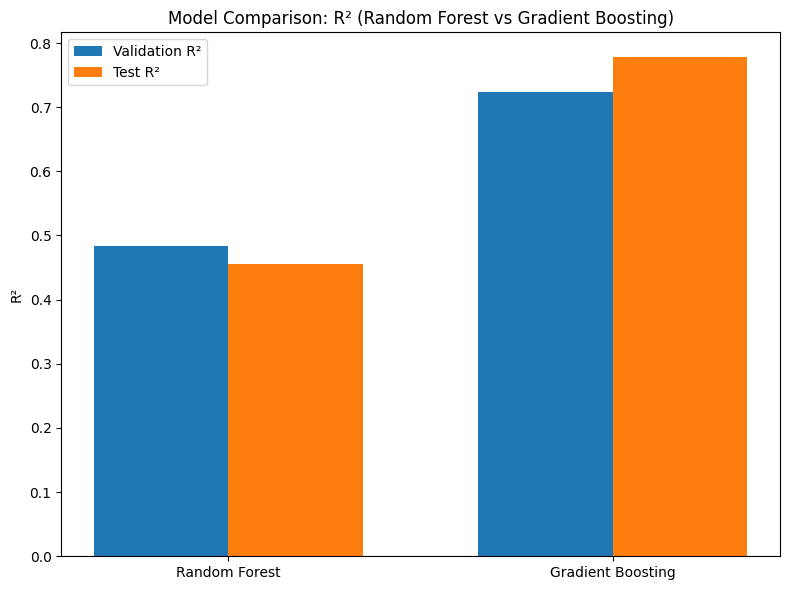

In [63]:
# Cell 1: R² comparison for Random Forest & Gradient Boosting

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parents[0]
METRICS_PATH = PROJECT_ROOT / "results" / "metrics.json"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load metrics
with open(METRICS_PATH, "r") as f:
    metrics = json.load(f)

models_to_plot = ["random_forest", "gradient_boosting"]

r2_val = []
r2_test = []

for m in models_to_plot:
    r2_val.append(metrics[m]["val"]["r2"])
    r2_test.append(metrics[m]["test"]["r2"])

x = np.arange(len(models_to_plot))
width = 0.35

plt.figure(figsize=(8, 6))
plt.bar(x - width/2, r2_val, width, label="Validation R²")
plt.bar(x + width/2, r2_test, width, label="Test R²")

plt.xticks(x, ["Random Forest", "Gradient Boosting"], rotation=0)
plt.ylabel("R²")
plt.title("Model Comparison: R² (Random Forest vs Gradient Boosting)")
plt.axhline(0, color="gray", linewidth=0.8)
plt.legend()
plt.tight_layout()

save_path = FIGURES_DIR / "rf_vs_gb_r2_comparison.png"
plt.savefig(save_path, dpi=300)
print(f"Saved R² comparison plot to: {save_path}")

plt.show()


Top 25 most important features:


,feature,importance
10,club_mean_value,0.773900
0,age,0.063861
6,nb_on_pitch,0.054685
2,assists,0.023222
11,country_mean_value,0.020829
3,goal_contrib,0.017462
8,days_missed,0.015992
4,minutes_played,0.010078
5,nb_in_group,0.008068
9,height,0.005104


Saved top-25 feature importance to: c:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project\reports\figures\gradient_boosting_feature_importance_top25.csv
Saved feature importance plot to: c:\Users\justi\OneDrive\Documents\UMD\Senior\INST414\INST414-Project\INST414-Project\reports\figures\gradient_boosting_feature_importance_top20.png


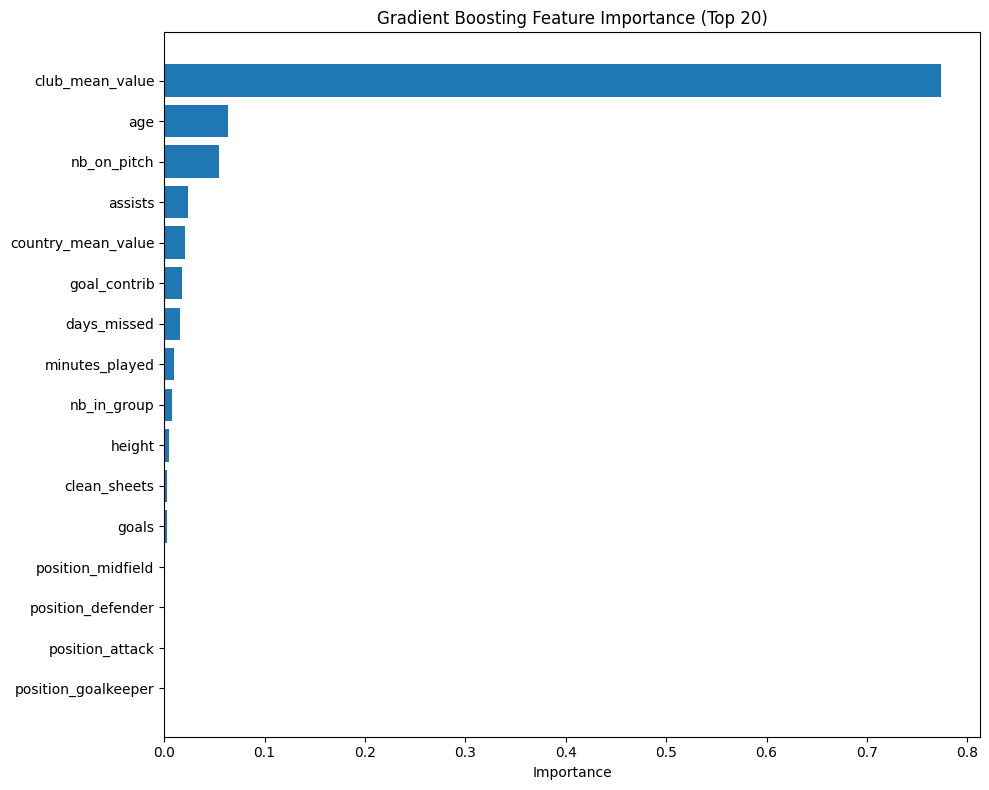

In [57]:
# Cell 4: Feature importance for Gradient Boosting model

gb_path = MODELS_DIR / "gradient_boosting_log_target.joblib"
gb_model = joblib.load(gb_path)

# The pipeline: preprocess (ColumnTransformer) + model (GradientBoostingRegressor)
preprocessor = gb_model.named_steps["preprocess"]
gb_reg = gb_model.named_steps["model"]

# Get feature names from the preprocessor
feature_names = []

for name, transformer, cols in preprocessor.transformers_:
    if name == "num":
        # numeric features stay as-is
        feature_names.extend(cols)
    elif name == "cat":
        # categorical → need to get one-hot names
        ohe = transformer
        # scikit-learn <=1.1: use get_feature_names
        try:
            ohe_names = ohe.get_feature_names(cols)
        except Exception:
            # newer versions: get_feature_names_out
            ohe_names = ohe.get_feature_names_out(cols)
        feature_names.extend(list(ohe_names))

importances = gb_reg.feature_importances_
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Top 25 most important features:")
display(feat_imp.head(25))

# Save to CSV if you want
fi_path = FIGURES_DIR / "gradient_boosting_feature_importance_top25.csv"
feat_imp.head(25).to_csv(fi_path, index=False)
print(f"Saved top-25 feature importance to: {fi_path}")

# Plot top 20
top_n = 20
top_feats = feat_imp.head(top_n).iloc[::-1]  # reverse for nicer horizontal bar plot

plt.figure(figsize=(10, 8))
plt.barh(top_feats["feature"], top_feats["importance"])
plt.xlabel("Importance")
plt.title(f"Gradient Boosting Feature Importance (Top {top_n})")
plt.tight_layout()

fi_fig_path = FIGURES_DIR / "gradient_boosting_feature_importance_top20.png"
plt.savefig(fi_fig_path, dpi=300)
print(f"Saved feature importance plot to: {fi_fig_path}")
plt.show()


In [ ]:
# Fixed Cell: Gradient Boosting actual vs predicted scatter (full data)
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "merged_players_dataset.csv"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load trained Gradient Boosting pipeline
gb_path = MODELS_DIR / "gradient_boosting_log_target.joblib"
gb_model = joblib.load(gb_path)

print("Loaded model from:", gb_path)
print("Data path:", DATA_PATH)

# 1) Load data
df = pd.read_csv(DATA_PATH)

# Keep only rows with positive market value
df = df[df["market_value_eur"] > 0].copy()

# 2) Make sure age exists (in case it isn't stored explicitly)
if "age" not in df.columns and "date_of_birth" in df.columns:
    df["date_of_birth"] = pd.to_datetime(df["date_of_birth"], errors="coerce")
    current_year = datetime.now().year
    df["age"] = current_year - df["date_of_birth"].dt.year

# 3) Recreate engineered features used in training
#    Average market value by current club
if "current_club_name" in df.columns:
    df["club_mean_value"] = (
        df.groupby("current_club_name")["market_value_eur"]
        .transform("mean")
    )
else:
    df["club_mean_value"] = df["market_value_eur"].mean()

#    Average market value by country of birth
if "country_of_birth" in df.columns:
    df["country_mean_value"] = (
        df.groupby("country_of_birth")["market_value_eur"]
        .transform("mean")
    )
else:
    df["country_mean_value"] = df["market_value_eur"].mean()

# 4) Rebuild the feature set
candidate_features = [
    "age",
    "goals",
    "assists",
    "minutes_played",
    "clean_sheets",
    "days_missed",
    "height",
    "nb_in_group",
    "nb_on_pitch",
    "goal_contrib",
    "club_mean_value",
    "country_mean_value",
    "position",
    "current_club_name",
    "country_of_birth",
]

feature_cols = [c for c in candidate_features if c in df.columns]

# Drop rows missing any features
df = df.dropna(subset=feature_cols + ["market_value_eur"])

X = df[feature_cols].copy()
y_true = df["market_value_eur"].astype(float)

print("Shape used for predictions:", X.shape)
print("Feature columns used:", feature_cols)

# 5) Predict with the pipeline (outputs log1p, so invert)
y_pred_log = gb_model.predict(X)
y_pred = np.expm1(y_pred_log)

# 6) Scatter plot: actual vs predicted
plt.figure(figsize=(7, 7))
plt.scatter(y_true, y_pred, alpha=0.3, s=10)
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color="red", linewidth=2, label="Perfect prediction")
plt.xlabel("Actual Market Value (€)")
plt.ylabel("Predicted Market Value (€)")
plt.title("Gradient Boosting: Actual vs Predicted Market Value (Full Data)")
plt.legend()
plt.tight_layout()

scatter_path = FIGURES_DIR / "gradient_boosting_actual_vs_predicted.png"
plt.savefig(scatter_path, dpi=300)
print(f"Saved actual vs predicted plot to: {scatter_path}")
plt.show()


ValueError: columns are missing: {'club_mean_value', 'country_mean_value'}